# 🔍 AI Evaluation Error Analysis Toolkit

## Overview

This notebook provides a comprehensive error analysis toolkit for AI evaluation data. It helps you understand patterns in evaluation failures, identify common issues, and gain insights into how to improve your AI system's performance.

## What This Toolkit Does

🎯 **Identifies Error Patterns**: Automatically groups similar evaluation failures together  
📊 **Visualizes Results**: Creates interactive charts and visualizations  
🤖 **AI-Powered Insights**: Uses LLMs to generate meaningful error categories and descriptions  
💡 **Actionable Recommendations**: Provides suggestions for improving your AI system  

## Key Features

- **Flexible Filtering**: Choose between analyzing all imperfect evaluations or just failures
- **Smart Clustering**: Groups similar errors together using AI-powered analysis
- **Interactive Exploration**: Click through charts to drill down into specific error types
- **Rich Visualizations**: Multiple chart types to understand your data from different angles
- **Full Context**: See the actual conversations that led to evaluation failures

## Prerequisites

Before running this notebook, ensure you have:
- Evaluation data in the expected format (see Data Structure section below)
- OpenAI/Azure OpenAI credentials configured for LLM analysis
- Required Python packages installed

Let's get started! 🚀

# 🛠️ Setup and Configuration

## Environment Setup

This notebook requires several dependencies and configuration steps:

### 1. Install Required Packages
```bash
pip install matplotlib seaborn wordcloud plotly ipywidgets
```

### 2. Configure OpenAI/Azure OpenAI (for LLM analysis)
Create a `.env` file with your credentials:
```env
AZURE_OPENAI_API_KEY=your_api_key_here
AZURE_OPENAI_ENDPOINT=https://your-endpoint.openai.azure.com/
AZURE_OPENAI_API_VERSION=2024-02-01
AZURE_OPENAI_DEPLOYMENT_NAME=your_deployment_name
```



### 3. Enable Auto-reload
The cell below enables automatic reloading of modules, so changes to the error analyzer code are picked up automatically.

In [1]:
%load_ext autoreload
%autoreload 2

# 📦 Import Analysis Toolkit

Now we'll import our error analysis tools:
- **`ErrorAnalyzer`**: The main class that performs error pattern analysis
- **`load_evaluation_data_with_samples`**: Utility to load evaluation data with full conversation context. Critic agent can use the output of its evaluate method as the input. Here, for better demonstration we are using loading the evaluations from a pre-calculated evaluation run.

In [2]:
from error_analyzer import ErrorAnalyzer
from utils import load_evaluation_data, load_evaluation_data_with_samples


# 📊 Load and Explore Your Data

## Data Loading

We'll load evaluation data that contains both:
1. **Evaluation Results**: Scores, pass/fail results, and detailed reasons
2. **Original Samples**: Full conversation data with queries and responses

## Expected Data Structure

Your evaluation data should follow this structure:
```python
{
    'thread_id': 'unique_identifier',
    'results': {
        'EvaluationType1': {
            'evaluationtype1': 4.0,  # score (0-5)
            'evaluationtype1_result': 'pass',  # or 'fail'
            'evaluationtype1_reason': 'Detailed explanation of the evaluation...'
        },
        'EvaluationType2': {
            # similar structure for other evaluation types
        }
    }
}
```

Let's load your data and examine its structure:

In [3]:
# Load both evaluation data and original samples
sample_evaluations, original_samples = load_evaluation_data_with_samples("allv2MSAIshopping.jsonl")
print(f"Loaded {len(sample_evaluations)} evaluations and {len(original_samples)} original samples")

Loaded 100 evaluations and 100 original samples from JSONL file
Loaded 100 evaluations and 100 original samples


## Understanding Original Sample Data

The original samples contain the full conversation context that was evaluated. This includes:
- User queries and inputs
- System responses and outputs  
- Conversation metadata
- Any additional context used during evaluation

This rich context is crucial for understanding why certain evaluations failed.

In [4]:
# Show structure of original sample data (with full conversation content)
print("Original sample structure (contains full conversation data):")
print("Keys:", list(original_samples[2].keys()))
print("\nSample original data:")
original_samples[2]

Original sample structure (contains full conversation data):
Keys: ['inputs.query', 'inputs.response', 'inputs.tool_definitions', 'outputs.intent_resolution.intent_resolution', 'outputs.intent_resolution.intent_resolution_result', 'outputs.intent_resolution.intent_resolution_threshold', 'outputs.intent_resolution.intent_resolution_reason', 'outputs.task_adherence.task_adherence', 'outputs.task_adherence.task_adherence_result', 'outputs.task_adherence.task_adherence_threshold', 'outputs.task_adherence.task_adherence_reason', 'outputs.relevance.relevance', 'outputs.relevance.gpt_relevance', 'outputs.relevance.relevance_reason', 'outputs.relevance.relevance_result', 'outputs.relevance.relevance_threshold', 'line_number', 'thread_id']

Sample original data:


{'inputs.query': [{'createdAt': '2025-06-20T09:39:26Z',
   'role': 'user',
   'content': [{'type': 'text',
     'text': 'Please help me find a Socks. null'}]}],
 'inputs.response': [{'createdAt': '2025-06-20T09:39:26Z',
   'run_id': '698fbb39b196f79fd2b2cd6ac7c7d3bf',
   'role': 'assistant',
   'content': [{'type': 'text',
     'text': "Absolutely! Here are some fantastic **socks** that blend style and sustainability. From the playful **Peanuts Tropical Socks** to the elegant **Kodak Socks**, there's something for everyone. Would you like more details on any specific pair?"}]}],
 'inputs.tool_definitions': [],
 'outputs.intent_resolution.intent_resolution': 3,
 'outputs.intent_resolution.intent_resolution_result': 'pass',
 'outputs.intent_resolution.intent_resolution_threshold': 3,
 'outputs.intent_resolution.intent_resolution_reason': 'User wanted help finding socks. Agent provided a list of options with brief descriptions, but did not clarify where or how to purchase them, leaving th

# 🧠 Generate Enhanced Error Analysis Report

## What This Analysis Does

The `generate_enhanced_report()` method performs a comprehensive 5-step analysis:

### Step 1: Filter Imperfect Evaluations
- **`fails_only=True`**: Only analyzes evaluations marked as "fail"
- **`fails_only=False`**: Analyzes all evaluations with scores < 5.0 (not perfect)

### Step 2: Extract Error Patterns
- Analyzes frequency of different evaluation types with issues
- Examines score distributions
- Extracts detailed error reasons

### Step 3: Generate Error Tags
- Uses AI to create short, descriptive names for each error reason
- Makes complex error descriptions easier to understand and categorize

### Step 4: Cluster Similar Errors
- Groups related errors together using semantic similarity
- Assigns weights based on frequency
- Creates meaningful cluster descriptions

### Step 5: AI-Powered Analysis (Optional)
- Generates insights about common patterns
- Provides recommendations for improvement
- Summarizes key findings

## Configuration Parameters

- **`evaluations`**: Your evaluation data
- **`fails_only=True`**: Focus only on failed evaluations (recommended for initial analysis)
- **`num_clusters=10`**: Maximum number of error clusters to create

Let's run the analysis on your data:

In [5]:
# Initialize the ErrorAnalyzer
analyzer = ErrorAnalyzer()
report = analyzer.generate_enhanced_report(
    evaluations = sample_evaluations,
    fails_only = True,
    num_clusters = 10
)
report

using model gpt-4.1
Step 1: Filtering imperfect evaluations...
Step 2: Extracting error patterns...
Step 3: Generating short error tags...
Step 4: Clustering error tags...
Step 5: Generating LLM analysis...


{'summary': {'total_evaluations': 100,
  'imperfect_evaluations': 40,
  'total_issues': 87,
  'filter_mode': 'fails_only',
  'unique_error_types': 85,
  'total_reasons_analyzed': 87},
 'patterns': {'evaluation_types': defaultdict(int,
              {'IntentResolution': 29, 'TaskAdherence': 33, 'Relevance': 25}),
  'score_distribution': defaultdict(<function error_analyzer.ErrorAnalyzer.extract_error_patterns.<locals>.<lambda>()>,
              {'IntentResolution': defaultdict(int, {2: 18, 1: 11}),
               'TaskAdherence': defaultdict(int, {2: 25, 1: 8}),
               'Relevance': defaultdict(int, {2: 15, 1: 10})}),
  'reasons': defaultdict(list,
              {'IntentResolution': ['User wanted to know when the Condroi pants in size 48 would be available. The agent failed to provide any specific information or actionable steps to resolve the query, offering only a vague suggestion to check FAQs.',
                "User wanted a return ticket, likely for travel. Agent misunderst

# 📈 Visualize Error Clusters

## Static Visualization Overview

The `visualize_cluster_results()` method creates two key charts:

### 1. Cluster Weights Distribution (Top Chart)
- **Horizontal bar chart** showing the frequency of each error cluster
- **Bars are sorted** by frequency (most common errors at the bottom)
- **Numbers on bars** show exact count of errors in each cluster

### 2. Error Distribution Pie Chart (Bottom Chart)  
- **Proportional view** of how errors are distributed across clusters
- **Coverage percentage** shows how much of your error data is captured
- **Interactive labels** help identify specific error types

## Key Insights to Look For
- **Dominant error types**: Which clusters have the highest weights?
- **Long tail of errors**: Are there many small, unique error types?
- **Coverage**: Is the clustering capturing most of your errors effectively?

Let's visualize your error clusters:

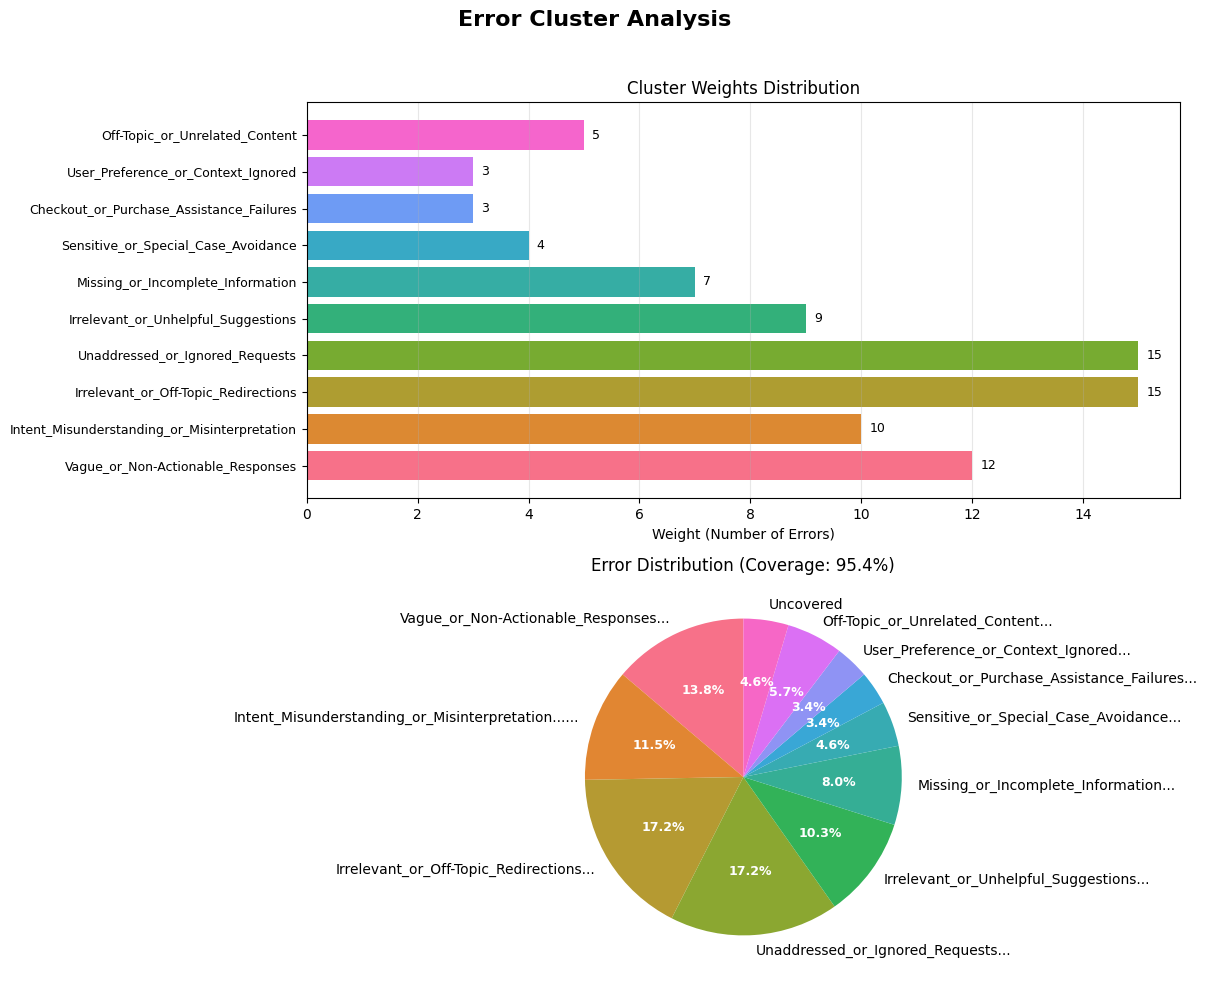

In [6]:
analyzer.visualize_cluster_results(
    cluster_results = report["error_clusters"]
)

# 🎯 Interactive Error Exploration

## Three-Level Drill-Down Analysis

The interactive visualization provides a powerful way to explore your errors in detail:

### 🥧 Level 1: Cluster Overview (Pie Chart)
- **Click on any pie slice** to explore that error cluster
- See the **relative size** of each error category
- **Hover** for detailed information about each cluster

### 📊 Level 2: Error Tags (Bar Chart)  
- After clicking a cluster, see **specific error types** within it
- **Horizontal bars** show frequency of each error tag
- **Click on any bar** to see actual conversation samples

### 💬 Level 3: Full Conversations (Sample Details)
- View **complete conversation context** that led to errors
- See **user queries and system responses**
- **Evaluation details** with scores and detailed reasons
- **Navigate back** through the hierarchy with back buttons

## What Makes This Powerful

- **Rich Context**: See the actual conversations, not just error summaries
- **Interactive Navigation**: Click-through interface, no dropdowns needed  
- **Formatted Display**: Well-formatted conversations and evaluation details
- **Limited Samples**: Shows first 3 samples per error tag for focused analysis

## How to Use It

1. **Start**: Look at the pie chart showing all error clusters
2. **Explore**: Click on the largest or most interesting clusters
3. **Deep Dive**: Click on specific error tags to see real examples
4. **Analyze**: Examine the conversations to understand root causes

Let's create your interactive dashboard:

In [9]:
# Enhanced Interactive Drill-Down with Clickable Charts
# The pie chart slices are now clickable - no need for dropdowns!

print("🎯 Creating Clickable Interactive Error Analysis Dashboard...")
print("✨ Features:")
print("   • Click on pie chart slices to explore clusters")
print("   • Click on bar chart bars to view full samples")
print("   • Well-formatted conversation display")
print("   • Cluster-based evaluation details")
print()

# Debug: Check if clusters data exists
print("🔍 Debugging cluster data:")
if 'error_clusters' in report:
    clusters = report['error_clusters'].get('clusters', {})
    print(f"   Number of clusters found: {len(clusters)}")
    if clusters:
        print(f"   Cluster names: {list(clusters.keys())[:3]}...")  # Show first 3
        total_weight = sum(cluster['weight'] for cluster in clusters.values())
        print(f"   Total weight: {total_weight}")
    else:
        print("   ❌ No clusters found in report!")
else:
    print("   ❌ No 'error_clusters' key in report!")

print()

# Pass the original samples to show full conversation data
analyzer.create_interactive_drill_down(report, original_evaluations=original_samples)

🎯 Creating Clickable Interactive Error Analysis Dashboard...
✨ Features:
   • Click on pie chart slices to explore clusters
   • Click on bar chart bars to view full samples
   • Well-formatted conversation display
   • Cluster-based evaluation details

🔍 Debugging cluster data:
   Number of clusters found: 10
   Cluster names: ['Vague_or_Non-Actionable_Responses', 'Intent_Misunderstanding_or_Misinterpretation', 'Irrelevant_or_Off-Topic_Redirections']...
   Total weight: 83

🎯 Interactive Error Analysis Dashboard
💡 Instructions:
   • Click on pie chart slices to explore clusters
   • Click on bar chart bars to see individual samples
   • Use back buttons to navigate between levels

